In [3]:
#import statements
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder

In [4]:
#CSV upload
gender_classification_csv="C:\\Users\\hp\\Documents\\Nandhini\\Gender_Project\\gender_classification.csv"
df=pd.read_csv(gender_classification_csv)
df

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
0,1,11.8,6.1,1,0,1,1,Male
1,0,14.0,5.4,0,0,1,0,Female
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
4,1,13.5,5.9,0,0,0,0,Female
...,...,...,...,...,...,...,...,...
4996,1,13.6,5.1,0,0,0,0,Female
4997,1,11.9,5.4,0,0,0,0,Female
4998,1,12.9,5.7,0,0,0,0,Female
4999,1,13.2,6.2,0,0,0,0,Female


In [5]:
#Preprocessing - (i) Missing Values
print("Missing Values:\n",df.isnull().sum())

Missing Values:
 long_hair                    0
forehead_width_cm            0
forehead_height_cm           0
nose_wide                    0
nose_long                    0
lips_thin                    0
distance_nose_to_lip_long    0
gender                       0
dtype: int64


In [6]:
#(ii)- Duplicate Values
print("Duplicate Values:\n",df.duplicated().sum())

Duplicate Values:
 1768


In [7]:
#Drop Duplicates
df=df.drop_duplicates()
#Recheck
print("Duplicate Values:\n",df.duplicated().sum())

Duplicate Values:
 0


In [13]:
#Target Values
X=df.drop("gender",axis=1)
y=df["gender"]

In [21]:
#Label Encoder
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])

C:\Users\hp\AppData\Local\Temp\ipykernel_9220\3389330695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["gender"] = le.fit_transform(df["gender"])


In [15]:
#Train-Test
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42)

In [16]:
#Model Train
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [17]:
#Model Predict
y_pred=model.predict(X_test)
acc=accuracy_score(y_test,y_pred)
rpt=classification_report(y_test,y_pred)
con=confusion_matrix(y_test,y_pred)
print("\n Logistic Regression Results:\n")
print("Accuracy Score:",acc)
print("Classification Report\n",rpt)
print("Confusion Matrix\n",con)


 Logistic Regression Results:

Accuracy Score: 0.9556701030927836
Classification Report
               precision    recall  f1-score   support

           0       0.96      0.95      0.95       457
           1       0.96      0.96      0.96       513

    accuracy                           0.96       970
   macro avg       0.96      0.96      0.96       970
weighted avg       0.96      0.96      0.96       970

Confusion Matrix
 [[434  23]
 [ 20 493]]


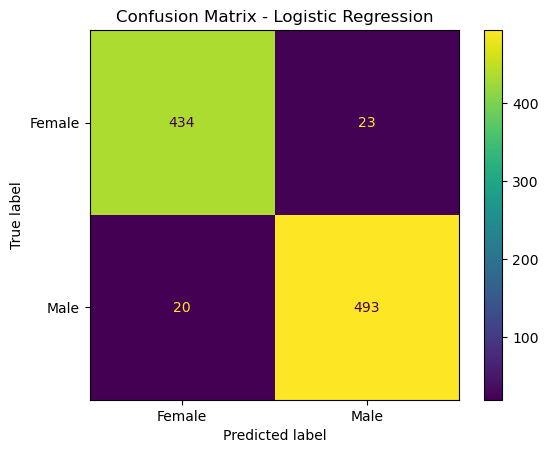

In [18]:
#confusion matrix display
disp=ConfusionMatrixDisplay(confusion_matrix=con,display_labels=["Female","Male"])
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [20]:
#External Prediction

new_data = [[0, 13.5, 6.2, 1, 1, 0, 1]]  # Example new input

# Column names must match training data
new_data_df = pd.DataFrame(new_data, columns=X.columns)

# Predict again
log_result = model.predict(new_data_df)[0]


print("Logistic Regression:", le.inverse_transform([log_result])[0])


Logistic Regression: 1
